<a href="https://colab.research.google.com/github/DanielVincentIon/loan-approval-ml-model/blob/main/loan_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Loan Approval Prediction Using Machine Learning
This notebook develops and evaluates supervised machine learning models to predict loan approval outcomes. The target variable is 'loan_status' and the models compared are Logistic Regression and Random Forest. The workflow includes data inspection, preprocessing, training, evaluation on unseen test data, and a brief discussion on bias and limitations.

# Sections:
## 1. Import Libraries
## 2. Load the Dataset
## 3. Explore and Clean The Data
## 4. Preprocessing
## 5. Train-Test Split
## 6. Logistic Regression Baseline
## 7. Random Forest Model
## 8. Model Evaluation
## 9. Feature Importance
## 10. Bias and Fairness
## 11. Limitations
## 12. Conclusion

# 1. Library Import

This section imports the Python libraries required for data handling, visualisation, preprocessing, model training, and evaluation. Pandas and NumPy are used for data manipulation. Matplotlib and Seaborn support data visualisation. Scikit-learn provides tools for splitting the dataset, preprocessing features, training classification models, and evaluating model performance.

In [98]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


# 2. Load the Dataset

This section loads the dataset into a pandas dataframe directly from a GitHub repository. This allows the data to be inspected and prepared for preprocessing and modelling.

In [99]:
url = "https://raw.githubusercontent.com/DanielVincentIon/loan-approval-ml-model/main/data/loan_data.csv"

df = pd.read_csv(url)
df.head()

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,22.0,female,Master,71948.0,0,RENT,35000.0,PERSONAL,16.02,0.49,3.0,561,No,1
1,21.0,female,High School,12282.0,0,OWN,1000.0,EDUCATION,11.14,0.08,2.0,504,Yes,0
2,25.0,female,High School,12438.0,3,MORTGAGE,5500.0,MEDICAL,12.87,0.44,3.0,635,No,1
3,23.0,female,Bachelor,79753.0,0,RENT,35000.0,MEDICAL,15.23,0.44,2.0,675,No,1
4,24.0,male,Master,66135.0,1,RENT,35000.0,MEDICAL,14.27,0.53,4.0,586,No,1


# 3. Explore and Clean the Data

This section explores the structure of the dataset, identifies variable types, and checks for issues such as missing values and class imbalance

In [100]:
df.info()
display(df.describe(include='all'))

class_counts = df['loan_status'].value_counts()
class_props = df['loan_status'].value_counts(normalize=True)

print("Class counts:")
display(class_counts)

print("\nClass proportions:")
display(class_props)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45000 entries, 0 to 44999
Data columns (total 14 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   person_age                      45000 non-null  float64
 1   person_gender                   45000 non-null  object 
 2   person_education                45000 non-null  object 
 3   person_income                   45000 non-null  float64
 4   person_emp_exp                  45000 non-null  int64  
 5   person_home_ownership           45000 non-null  object 
 6   loan_amnt                       45000 non-null  float64
 7   loan_intent                     45000 non-null  object 
 8   loan_int_rate                   45000 non-null  float64
 9   loan_percent_income             45000 non-null  float64
 10  cb_person_cred_hist_length      45000 non-null  float64
 11  credit_score                    45000 non-null  int64  
 12  previous_loan_defaults_on_file  

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
count,45000.000000,45000,45000,4.500000e+04,45000.000000,45000,45000.000000,45000,45000.000000,45000.000000,45000.000000,45000.000000,45000,45000.000000
unique,NaN,2,5,NaN,NaN,4,NaN,6,NaN,NaN,NaN,NaN,2,NaN
top,NaN,male,Bachelor,NaN,NaN,RENT,NaN,EDUCATION,NaN,NaN,NaN,NaN,Yes,NaN
freq,NaN,24841,13399,NaN,NaN,23443,NaN,9153,NaN,NaN,NaN,NaN,22858,NaN
mean,27.764178,NaN,NaN,8.031905e+04,5.410333,NaN,9583.157556,NaN,11.006606,0.139725,5.867489,632.608756,NaN,0.222222
std,6.045108,NaN,NaN,8.042250e+04,6.063532,NaN,6314.886691,NaN,2.978808,0.087212,3.879702,50.435865,NaN,0.415744
min,20.000000,NaN,NaN,8.000000e+03,0.000000,NaN,500.000000,NaN,5.420000,0.000000,2.000000,390.000000,NaN,0.000000
25%,24.000000,NaN,NaN,4.720400e+04,1.000000,NaN,5000.000000,NaN,8.590000,0.070000,3.000000,601.000000,NaN,0.000000
50%,26.000000,NaN,NaN,6.704800e+04,4.000000,NaN,8000.000000,NaN,11.010000,0.120000,4.000000,640.000000,NaN,0.000000
75%,30.000000,NaN,NaN,9.578925e+04,8.000000,NaN,12237.250000,NaN,12.990000,0.190000,8.000000,670.000000,NaN,0.000000


Class counts:


,count
loan_status,
0,35000
1,10000



Class proportions:


,proportion
loan_status,
0,0.777778
1,0.222222


In [101]:
# This section confirms whether any columns required imputation or removal. If no missing values are present, the dataset can proceed directly to the next cleaning stage #

print("Missing values by column:")
display(df.isnull().sum())

Missing values by column:


,0
person_age,0
person_gender,0
person_education,0
person_income,0
person_emp_exp,0
person_home_ownership,0
loan_amnt,0
loan_intent,0
loan_int_rate,0
loan_percent_income,0


In [102]:
# This section checks for duplicate rows prior to modelling because repeated observations can distort model training and evaluation. If duplicates are present, they require removal before further preprocessing #

duplicate_count = df.duplicated().sum()
print("Number of duplicate rows:", duplicate_count)

if duplicate_count > 0:
  df = df.drop_duplicates()
  print("Duplicates removed")

Number of duplicate rows: 0


## 4. Preprocessing

This section prepares the dataset for model training by separating the target variable from the predictor variables and converting categorical features into numerical form using one-hot encoding.

In [103]:
# This section prepares the dataset for model training by separating the target variable from the predictor variables and converting categorical features into numerical form.

X = df.drop('loan_status', axis=1)
y = df['loan_status']

X = pd.get_dummies(X, drop_first=True)

print("Encoded feature matrix shape:", X.shape)
X.info()

Encoded feature matrix shape: (45000, 22)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45000 entries, 0 to 44999
Data columns (total 22 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   person_age                          45000 non-null  float64
 1   person_income                       45000 non-null  float64
 2   person_emp_exp                      45000 non-null  int64  
 3   loan_amnt                           45000 non-null  float64
 4   loan_int_rate                       45000 non-null  float64
 5   loan_percent_income                 45000 non-null  float64
 6   cb_person_cred_hist_length          45000 non-null  float64
 7   credit_score                        45000 non-null  int64  
 8   person_gender_male                  45000 non-null  bool   
 9   person_education_Bachelor           45000 non-null  bool   
 10  person_education_Doctorate          45000 non-null  bool   
 11 

## 5. Train-Test Split and Scaling

This section divides the dataset into training and test sets using an 80/20 ratio and applies feature scaling for Logistic Regression. The scaler is fitted on the training data and then applied to the test data to prevent data leakage.

In [104]:
# This section splits the dataset into training and test sets using an 80/20 ratio. The training data is used to fit the model, while the test data is reserved for evaluating performance on unseen data. A fixed random state is used to ensure reproducibility of the results #

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [105]:
# This section standardises the numerical features using a StandardScaler to ensure that all variables are on a comparable scale. The scaler is fitted on the training data and then applied to both the training and test sets to prevent data leakage #

scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

numeric_cols = X_train.select_dtypes(include=np.number).columns
X_train_scaled[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test_scaled[numeric_cols] = scaler.transform(X_test[numeric_cols])

## 6. Logistic Regression Baseline

Logistic Regression is used as a baseline model because it is a standard and interpretable method for binary classification. It provides a useful benchmark against which a more flexible model can be compared.

In [106]:
# This section trains a Logistic Regression model using the training data #

lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=1000)

## 7. Random Forest Model

Random Forest is used as a second model because it can capture more complex and non-linear relationships between variables. It also handles feature interactions better than Logistic Regression and may therefore achieve stronger predictive performance on this dataset

In [107]:
# This section trains a Random Forest classifier using the training data #

rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

## 8. Model Evaluation

This section evaluates the performance of both models on the test dataset using classification metrics including precision, recall, and F1-score. These metrics provide a more complete assessment than accuracy alone #

In [108]:
y_pred_lr = lr.predict(X_test_scaled)
y_pred_rf = rf.predict(X_test)

print("Logistic Regression:")
print(classification_report(y_test, y_pred_lr))

print("Random Forest:")
print(classification_report(y_test, y_pred_rf))

Logistic Regression:
              precision    recall  f1-score   support

           0       0.93      0.94      0.94      7000
           1       0.79      0.75      0.77      2000

    accuracy                           0.90      9000
   macro avg       0.86      0.84      0.85      9000
weighted avg       0.90      0.90      0.90      9000

Random Forest:
              precision    recall  f1-score   support

           0       0.94      0.97      0.95      7000
           1       0.90      0.77      0.83      2000

    accuracy                           0.93      9000
   macro avg       0.92      0.87      0.89      9000
weighted avg       0.93      0.93      0.93      9000



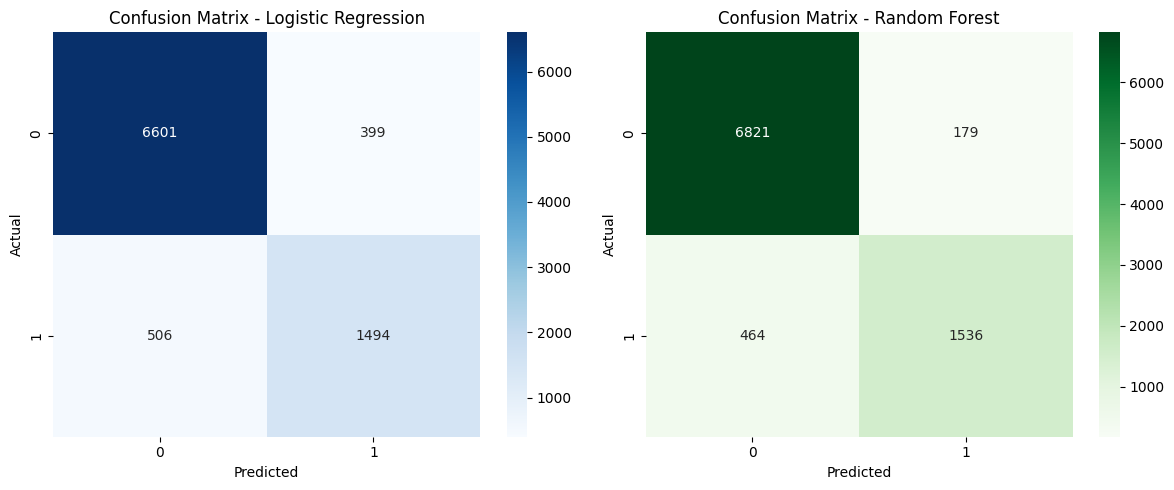

In [109]:
# This section visualises the confusion matrices for both models to show the types of errors made on unseen data #

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.heatmap(confusion_matrix(y_test, y_pred_lr), annot=True, fmt='d', ax=axes[0], cmap='Blues')
axes[0].set_title("Confusion Matrix - Logistic Regression")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")

sns.heatmap(confusion_matrix(y_test, y_pred_rf), annot=True, fmt='d', ax=axes[1], cmap='Greens')
axes[1].set_title("Confusion Matrix - Random Forest")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")

plt.tight_layout()
plt.show()

## 9. Feature Importance

This section examines which variables contribute most strongly to the Random Forest model's predictions. Feature importance helps to interpret the model and identify which factors appear most influential in loan approval decisions.

,0
previous_loan_defaults_on_file_Yes,0.218127
loan_percent_income,0.163793
loan_int_rate,0.157401
person_income,0.124549
loan_amnt,0.061482
person_home_ownership_RENT,0.056364
credit_score,0.054492
person_age,0.031961
person_emp_exp,0.028429
cb_person_cred_hist_length,0.026421


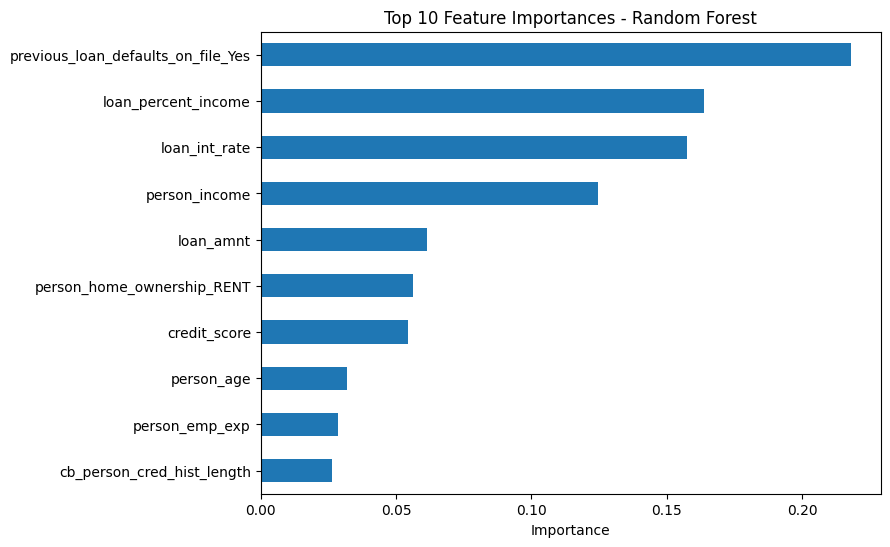

In [110]:
# This section examines the relative importance of each feature in the Random Forest model

feature_importances = pd.Series(rf.feature_importances_, index=X.columns)
top_features = feature_importances.sort_values(ascending=False).head(10)

display(top_features)

plt.figure(figsize=(8, 6))
top_features.sort_values().plot(kind='barh')
plt.title("Top 10 Feature Importances - Random Forest")
plt.xlabel("Importance")
plt.show()

## 10. Bias and Fairness Considerations

Although the model shows strong predictive performance, this does not guarantee fair outcomes. Some features in the dataset, such as gender, education, income, and home ownership, may reflect broader social inequalities. If historical lending decisions were biased, the model may learn and reproduce those patterns. In practice, this means performance should be evaluated not only in terms of accuracy and F1-score, but also in terms of fairness across different groups.

## 11. Limitations

This project has several limitations. First, only two classification models were tested, so other methods may perform differently. Second, the model was evaluated on a held-out test set from the same dataset, but not on external data, so its generalisability is uncertain. Third, although ethical concerns and potential bias have been discussed, fairness was not formally measured across demographic groups. Finally, strong predictive performance does not mean the model should be used in real-world lending decisions without further validation, transparency, and oversight.

## 12. Conclusion

This notebook developed and evaluated two supervised machine learning models for loan approval prediction. Logistic Regression provided a useful baseline, while Random Forest achieved the stronger overall performance on the held-out test set. The results suggest that affordability and past default history are important predictors of loan approval outcomes. However, the model has important limitations related to fairness, interpretability, and generalisability, so caution would be needed before any real-world deployment.